In [3]:
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [4]:
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from datasets.wmh import WMH
from datasets.dbb import DBB
from datasets.atlas import ATLAS
from collections import Counter

In [5]:
DBB_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/DBB"
WMH_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/WMH"
ATLAS_PREPROCESSED_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/ATLAS_R3.0_preprocessed"

In [ ]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
import ipywidgets as widgets


def explore_mri(img, mask, canonical=False, rotation=False):
    """
    :param img: filepath or nib or array
    """
    def get_data(src):
        if isinstance(src, str):
            nifti_data = nib.load(src)
            if canonical:
                nifti_data = nib.as_closest_canonical(nifti_data)
            data = nifti_data.get_fdata()
        elif isinstance(src, nib.Nifti1Image):
            data = src.get_fdata()
        else:
            data = np.asarray(src)

        return data
    
    # Get data
    data = get_data(img)
    mask = get_data(mask)
    
    # define dropdown menu selection for the plane of view
    plane_widget = Dropdown(
        options=["Sagittal", "Coronal", "Axial"],
        value="Axial",
        description="Plane:"
    )

    # define the slider for the images
    slice_slider = IntSlider(
        min=0,
        max=data.shape[2]-1,
        step=1,
        value=data.shape[2] // 2,
        description="Slice:",
        continuos_upldate=False
    )

    def update_slider(*args):
        plane = plane_widget.value

        if plane == "Axial":
            n_slices = data.shape[2]
        elif plane == "Coronal":
            n_slices = data.shape[1]
        else:  # Sagittal
            n_slices = data.shape[0]

        slice_slider.max = n_slices - 1
        slice_slider.value = n_slices // 2

    plane_widget.observe(update_slider, names="value")

    def show_slice(plane, slice_idx):
        fig, ax = plt.subplots(figsize=(10,10))

        if plane == "Axial":
            img_slice = data[:, :, slice_idx]
            mask_slice = mask[:, :, slice_idx]

        elif plane == "Coronal":
            img_slice = data[:, slice_idx, :]
            mask_slice = mask[:, slice_idx, :]

        elif plane == "Sagittal":
            img_slice = data[slice_idx, :, :]
            mask_slice = mask[slice_idx, :, :]

        if rotation:
            img_slice = np.rot90(img_slice)
            mask_slice = np.rot90(mask_slice)
        
        ax.imshow(img_slice, cmap="grey")
        ax.imshow(mask_slice, cmap="grey", alpha=(mask_slice > 0).astype(float))
        ax.set_title(f"Slice {slice_idx}")

        plt.show()

    # define dropdown and slicer interface
    ui = widgets.HBox([plane_widget, slice_slider])
    out = widgets.interactive_output(
        show_slice,
        {
            "plane": plane_widget,
            "slice_idx": slice_slider
        }
    )

    display(ui, out)

# ATLAS 3.0

In [18]:
df = ATLAS.get_metadata(ATLAS_PREPROCESSED_DATASET_FOLDER)
df.head(5)

,SESSION ID,DATASET,DAYS POST STROKE,CHRONICITY,SITE,T1W FILEPATH,SEGMENTATION FILEPATH
0,sub-r001s001_ses-1,Training,471.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s001...,ATLAS3_Training_Preprocessed/R001/sub-r001s001...
1,sub-r001s002_ses-1,Training,669.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s002...,ATLAS3_Training_Preprocessed/R001/sub-r001s002...
2,sub-r001s003_ses-1,Training,709.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s003...,ATLAS3_Training_Preprocessed/R001/sub-r001s003...
3,sub-r001s004_ses-1,Training,871.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s004...,ATLAS3_Training_Preprocessed/R001/sub-r001s004...
4,sub-r001s005_ses-1,Training,1917.0,NaN,R001,ATLAS3_Training_Preprocessed/R001/sub-r001s005...,ATLAS3_Training_Preprocessed/R001/sub-r001s005...


In [19]:
atlas2_df = df[df["DATASET"] != "ATLAS3"]

t1w_non_nan_filepath_count = atlas2_df['SEGMENTATION FILEPATH'].count()
segmentation_non_nan_filepath_count = atlas2_df['SEGMENTATION FILEPATH'].count()

print(f"T1W available: {t1w_non_nan_filepath_count}")
print(f"Segmentations available: {segmentation_non_nan_filepath_count}")

T1W available: 957
Segmentations available: 957


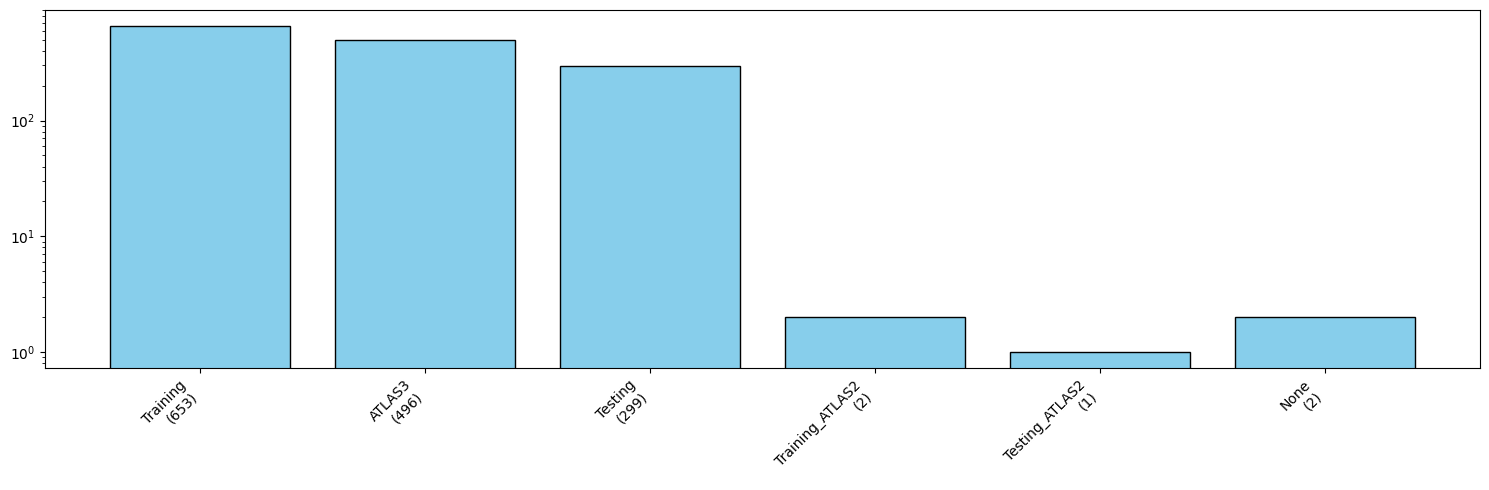

In [5]:
counts = Counter(df["DATASET"])
keys = [f"{key}\n({value})" if key is not None else f"None\n({value})" for key, value in counts.items()]

fig, ax = plt.subplots(figsize=(15,5))
ax.bar(keys, counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

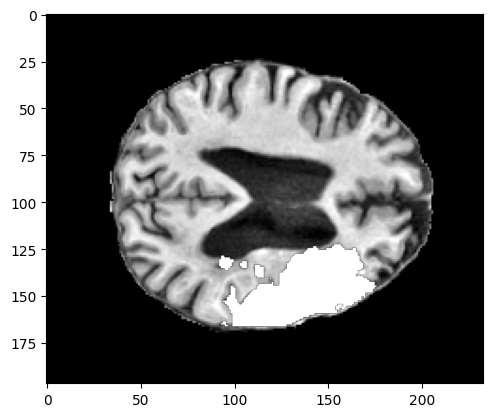

In [13]:
row = df.iloc()[0]

t1w_nib = nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['T1W FILEPATH']}")
mask_nib = nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{row['SEGMENTATION FILEPATH']}")

plt.imshow(t1w_nib.get_fdata()[:,:,100], cmap=plt.cm.gray)
plt.imshow(mask_nib.get_fdata()[:,:,100], alpha=(mask_nib.get_fdata()[:,:,100]>0).astype(float), cmap=plt.cm.gray)

## Compare available resolutions

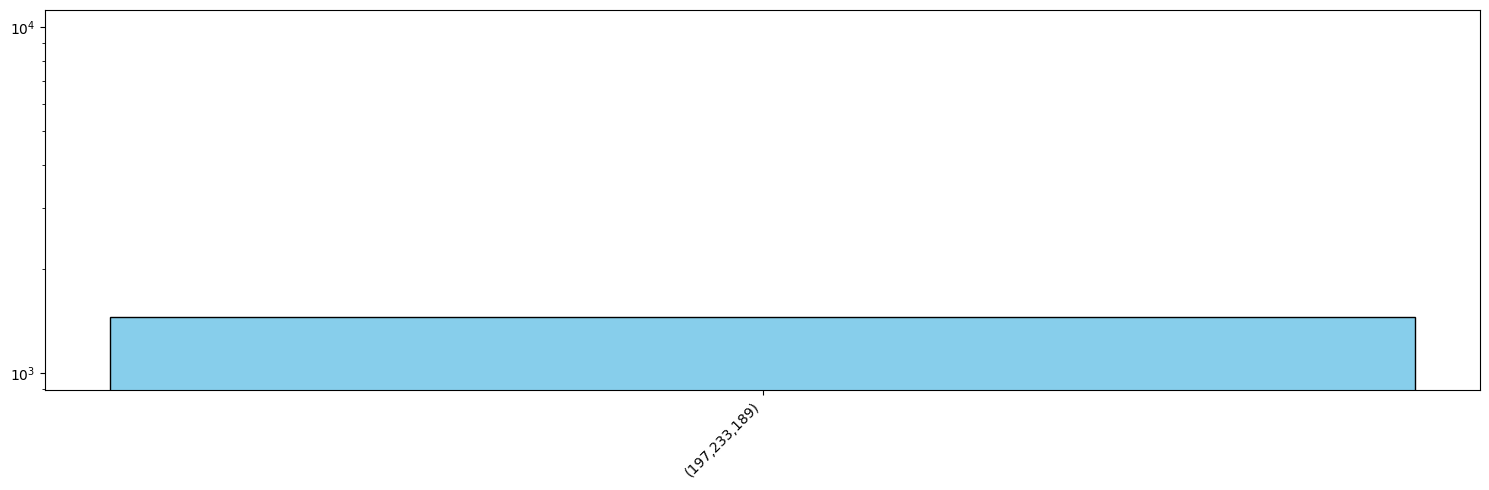

In [6]:
shapes = [
    nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").shape
    for t1w_filepath in df["T1W FILEPATH"]
]


counts = Counter(shapes)

fig, ax = plt.subplots(figsize=(15,5))
ax.bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [10]:
voxel_sizes = np.array([
    nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").header.get_zooms()
    for t1w_filepath in df["T1W FILEPATH"]
])

t1_x_mean, t1_x_std = np.mean(voxel_sizes[:,0]), np.std(voxel_sizes[:,0])
t1_y_mean, t1_y_std = np.mean(voxel_sizes[:,1]), np.std(voxel_sizes[:,1])
t1_z_mean, t1_z_std = np.mean(voxel_sizes[:,2]), np.std(voxel_sizes[:,2])
print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")

[T1] (1.00±0.00, 1.00±0.00, 1.00±0.00)


## Orientation

In [11]:
orientations = [
    "".join(nib.aff2axcodes(nib.load(f"{ATLAS_PREPROCESSED_DATASET_FOLDER}/{t1w_filepath}").affine))
    for t1w_filepath in df["T1W FILEPATH"]
]

print(np.unique_counts(orientations))

UniqueCountsResult(values=array(['RAS'], dtype='<U3'), counts=array([1453]))


# Distorted Brain Benchmark (DBB)

In [16]:
df = DBB.get_patients_metadata(DBB_DATASET_FOLDER)
scans_filepath = DBB.get_scans_filepath(DBB_DATASET_FOLDER) 

df.head()

,SUBJECT,ORIGINAL_ID,AGE,GENDER,SOURCE,CATEGORY,SET,ORIGINAL_FILENAME,MRI SEQUENCE,STATIC MAGNETIC FIELD,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE,AFFINE MATRIX FILE
0,0001,IRC04H_00F004_F_1,0.79,F,C-MIND,Healthy,train,IRC04H_00F004_F_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
1,0002,IRC04H_00F011_P_1,0.08,F,C-MIND,Healthy,train,IRC04H_00F011_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
2,0003,IRC04H_00F020_P_1,0.79,F,C-MIND,Healthy,train,IRC04H_00F020_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
3,0004,IRC04H_00F031_P_1,0.71,F,C-MIND,Healthy,train,IRC04H_00F031_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
4,0005,IRC04H_00F032_P_1,0.11,F,C-MIND,Healthy,train,IRC04H_00F032_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES


In [7]:
df[["T1-W FILE", "SEGMENTATION FILE", "BRAIN MASK FILE", "RAW BRAIN MASK FILE"]].describe()

,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE
count,955,955,955,955
unique,2,1,1,2
top,NO,YES,YES,YES
freq,711,955,955,711


## Compare the available resolutions

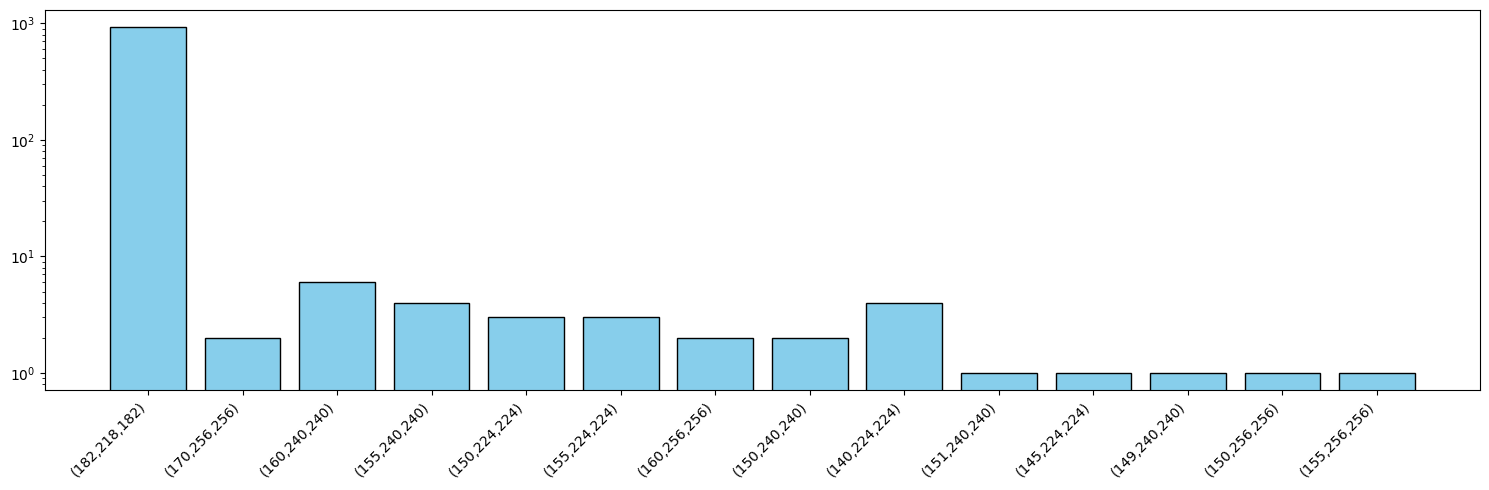

In [6]:
shapes = [
    nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").shape
    for scans in scans_filepath.values() 
]

counts = Counter(shapes)
fig, ax = plt.subplots(figsize=(15,5))
ax.bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [23]:
sizes = np.array([
    nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").header.get_zooms()
    for scans in list(scans_filepath.values())
])

t1_x_mean, t1_x_std = np.mean(sizes[:,0]), np.std(sizes[:,0])
t1_y_mean, t1_y_std = np.mean(sizes[:,1]), np.std(sizes[:,1])
t1_z_mean, t1_z_std = np.mean(sizes[:,2]), np.std(sizes[:,2])
print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")

[T1] (1.00±0.00, 1.00±0.01, 1.00±0.01)


## Orientation

In [31]:
orientations = [
    "".join(nib.aff2axcodes(nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").affine))
    for scans in list(scans_filepath.values())
]

print(np.unique_counts(orientations))

UniqueCountsResult(values=array(['LAS', 'RAS'], dtype='<U3'), counts=array([943,  12]))


## C-MIND

In [8]:
subject_id = "0001"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

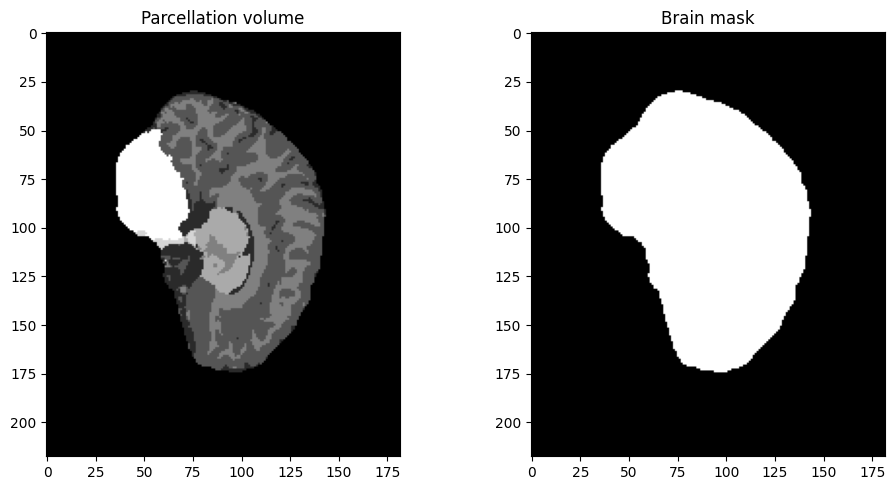

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

i = 100
axs[0].imshow(nib_segmentation.get_fdata()[i, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[i, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

Text(0.5, 1.0, 'Axial')

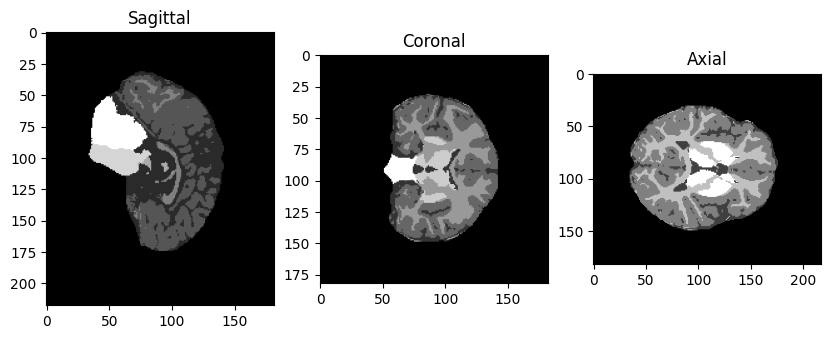

In [71]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Sagittal")

axs[1].imshow(nib_segmentation.get_fdata()[:, 109, :], cmap=plt.cm.gray)
axs[1].set_title("Coronal")

axs[2].imshow(nib_segmentation.get_fdata()[:, :, 91], cmap=plt.cm.gray)
axs[2].set_title("Axial")

## EMEDEA-PED

In [72]:
subject_id = "0415"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

t1_filepath = scans_filepath[subject_id]["T1-W FILEPATH"]
segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_t1 = nib.load(f"{DBB_DATASET_FOLDER}/{t1_filepath}")
nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

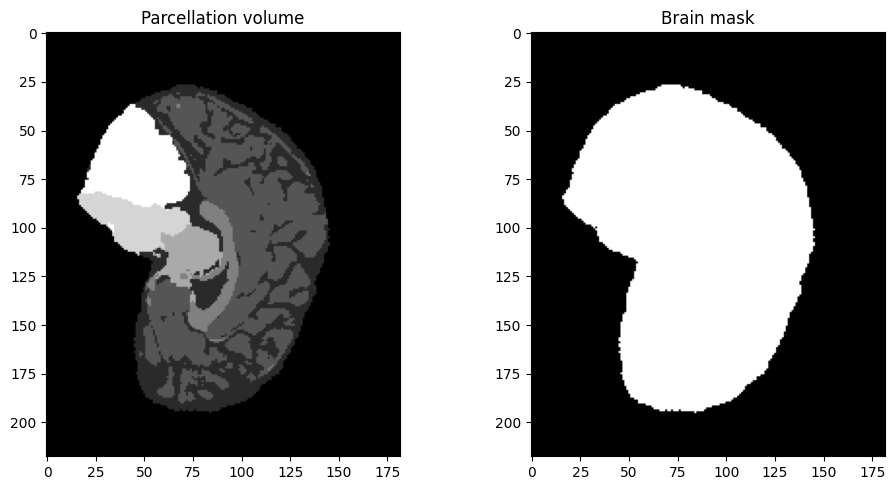

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

Text(0.5, 1.0, 'Axial')

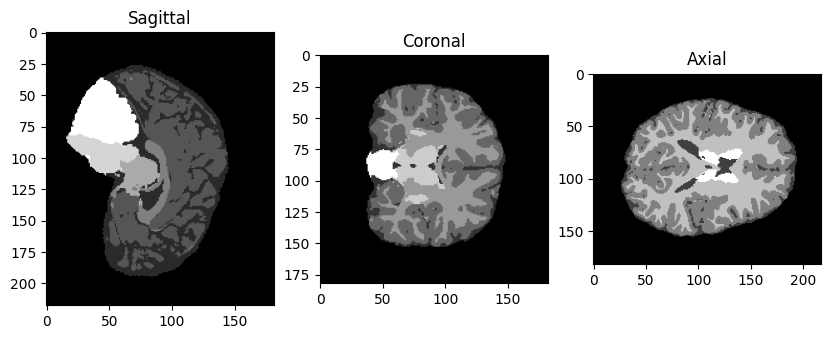

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Sagittal")

axs[1].imshow(nib_segmentation.get_fdata()[:, 109, :], cmap=plt.cm.gray)
axs[1].set_title("Coronal")

axs[2].imshow(nib_segmentation.get_fdata()[:, :, 91], cmap=plt.cm.gray)
axs[2].set_title("Axial")

## NIH-PED

In [78]:
subject_id = "0519"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

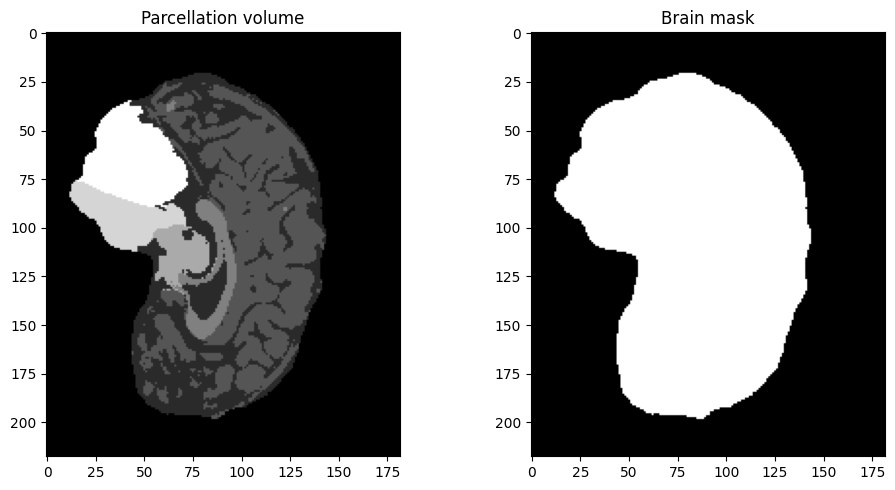

In [79]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

Text(0.5, 1.0, 'Axial')

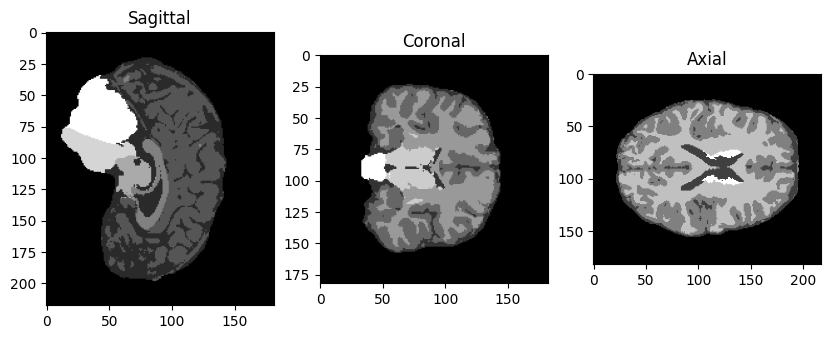

In [80]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Sagittal")

axs[1].imshow(nib_segmentation.get_fdata()[:, 109, :], cmap=plt.cm.gray)
axs[1].set_title("Coronal")

axs[2].imshow(nib_segmentation.get_fdata()[:, :, 91], cmap=plt.cm.gray)
axs[2].set_title("Axial")

# WMH

In [6]:
df = WMH.get_metadata(WMH_DATASET_FOLDER)
df.head()

,SET,CENTER,SCANNER,PATIENT,T1W FILEPATH,FLAIR FILEPATH,SEGMENTATION FILEPATH
0,training,Amsterdam,GE3T,100,wmh_data/training/Amsterdam/GE3T/100/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/100/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/100/wmh.nii
1,training,Amsterdam,GE3T,101,wmh_data/training/Amsterdam/GE3T/101/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/101/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/101/wmh.nii
2,training,Amsterdam,GE3T,102,wmh_data/training/Amsterdam/GE3T/102/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/102/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/102/wmh.nii
3,training,Amsterdam,GE3T,103,wmh_data/training/Amsterdam/GE3T/103/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/103/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/103/wmh.nii
4,training,Amsterdam,GE3T,104,wmh_data/training/Amsterdam/GE3T/104/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/104/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/104/wmh.nii


In [7]:
print("Number of patients: ", len(df))
print("Available T1W: ", df["T1W FILEPATH"].count())
print("Available FLAIR: ", df["FLAIR FILEPATH"].count())
print("Available SEGMENTATION: ", df["SEGMENTATION FILEPATH"].count())

Number of patients:  170
Available T1W:  170
Available FLAIR:  170
Available SEGMENTATION:  170


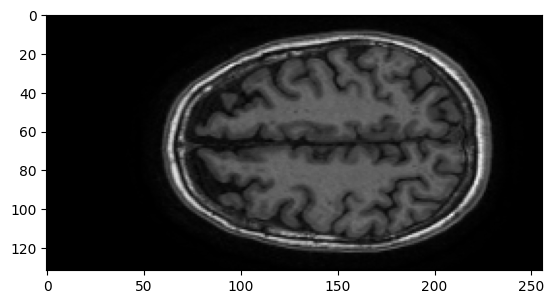

In [8]:
t1w_filepath, flair_filepath, segmentation_filepath = df.iloc()[0]["T1W FILEPATH"], df.iloc()[0]["FLAIR FILEPATH"], df.iloc()[0]["SEGMENTATION FILEPATH"]

t1w_data = nib.load(f"{WMH_DATASET_FOLDER}/{t1w_filepath}").get_fdata()
flair_data = nib.load(f"{WMH_DATASET_FOLDER}/{flair_filepath}").get_fdata()
segmentation_data = nib.load(f"{WMH_DATASET_FOLDER}/{segmentation_filepath}").get_fdata()

plt.imshow(t1w_data[:, :, 60], cmap=plt.cm.gray)

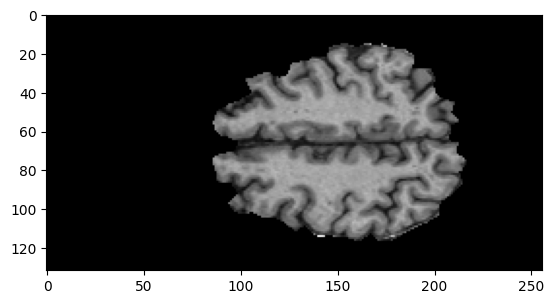

In [45]:
from fsl.wrappers import bet
from pathlib import Path
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    t1w_brain_filepath = f"{tmpdir}/T1w_brain.nii.gz"
    bet(
        f"{WMH_DATASET_FOLDER}/{t1w_filepath}",
        t1w_brain_filepath
    )

    t1w_brain_data = nib.load(t1w_brain_filepath).get_fdata()
    plt.imshow(t1w_brain_data[:,:,60], cmap=plt.cm.gray)

## Compare image resolutions among the dataset

In [7]:
center_sizes = {
    "Amsterdam": [],
    "Singapore": [],
    "Utrecht": []
}

for center in center_sizes.keys():
    dl = DataLoader(WMH(WMH_DATASET_FOLDER, data_split=None, center=center), batch_size=1, shuffle=False)

    for t1, flair, segmentation in dl:
        t1, flair, segmentation = t1.squeeze(0), flair.squeeze(0), segmentation.squeeze(0) # squeezing batch dimension

        if t1.size() != flair.size() != segmentation.size():
            print("Sizes mismatch")

        center_sizes[center].append(t1.size())

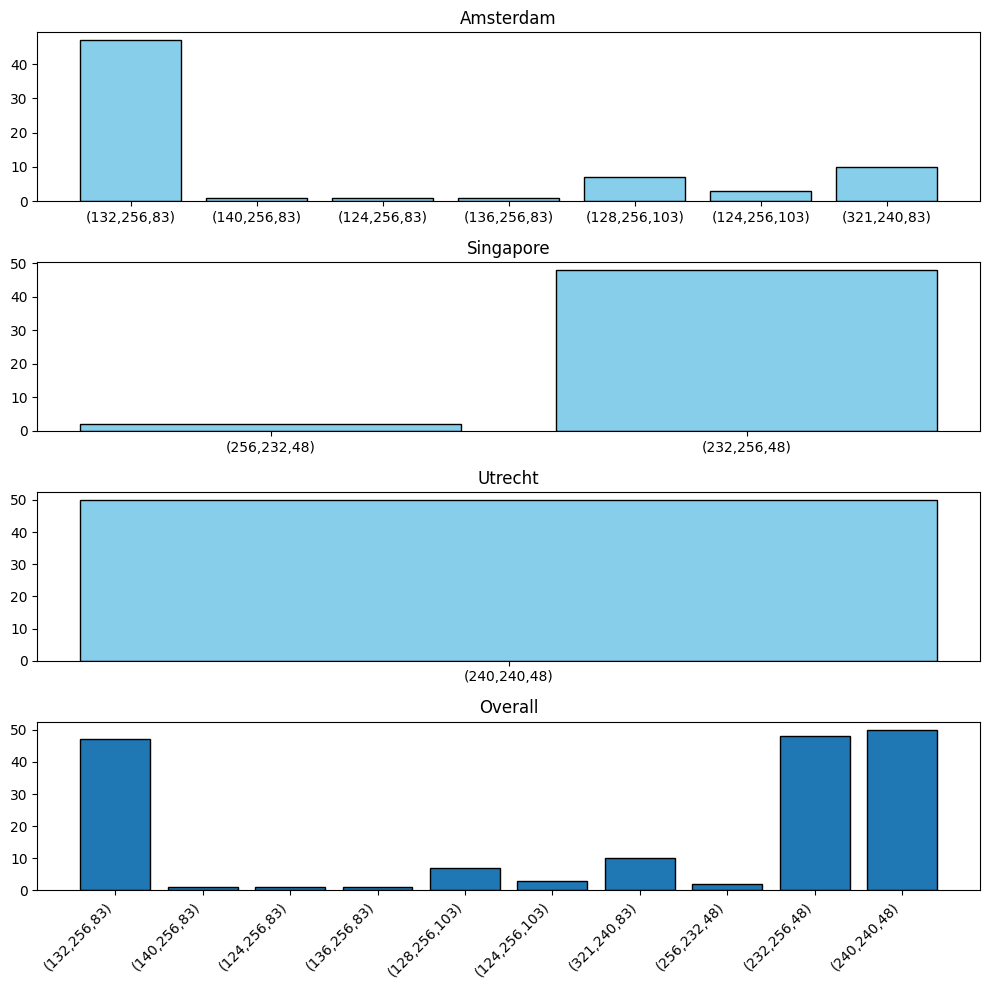

In [6]:
fig, axs = plt.subplots(4, figsize=(10, 10))

center = "Amsterdam"
counts = Counter(center_sizes[center])
axs[0].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[0].set_title(center)

center = "Singapore"
counts = Counter(center_sizes[center])
axs[1].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[1].set_title(center)

center = "Utrecht"
counts = Counter(center_sizes[center])
axs[2].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[2].set_title(center)

counts = Counter(center_sizes["Amsterdam"] + center_sizes["Singapore"] + center_sizes["Utrecht"])
axs[3].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), edgecolor='black')
axs[3].set_title("Overall")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [48]:
center_voxel_sizes = {
    center: {
        "t1": {
            "x": [], 
            "y": [], 
            "z": []
        },
        "flair": {
            "x": [], 
            "y": [], 
            "z": []
        }
    }
    for center in ["Amsterdam", "Singapore", "Utrecht"]
}

# AMSTERDAM
for scans_path in ["wmh_data/training/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE1T5", "wmh_data/test/Amsterdam/Philips_VU .PETMR_01."]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Amsterdam"]["t1"]["x"].append(x)
        center_voxel_sizes["Amsterdam"]["t1"]["y"].append(y)
        center_voxel_sizes["Amsterdam"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Amsterdam"]["flair"]["x"].append(x)
        center_voxel_sizes["Amsterdam"]["flair"]["y"].append(y)
        center_voxel_sizes["Amsterdam"]["flair"]["z"].append(z)

# SINGAPORE
for scans_path in ["wmh_data/training/Singapore", "wmh_data/test/Singapore"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Singapore"]["t1"]["x"].append(x)
        center_voxel_sizes["Singapore"]["t1"]["y"].append(y)
        center_voxel_sizes["Singapore"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Singapore"]["flair"]["x"].append(x)
        center_voxel_sizes["Singapore"]["flair"]["y"].append(y)
        center_voxel_sizes["Singapore"]["flair"]["z"].append(z)

# UTRECHT
for scans_path in ["wmh_data/training/Utrecht", "wmh_data/test/Utrecht"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Utrecht"]["t1"]["x"].append(x)
        center_voxel_sizes["Utrecht"]["t1"]["y"].append(y)
        center_voxel_sizes["Utrecht"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Utrecht"]["flair"]["x"].append(x)
        center_voxel_sizes["Utrecht"]["flair"]["y"].append(y)
        center_voxel_sizes["Utrecht"]["flair"]["z"].append(z)

In [49]:
for center in ["Amsterdam", "Singapore", "Utrecht"]:
    print(f"-- {center} --")
    t1_x_mean, t1_x_std = np.mean(center_voxel_sizes[center]["t1"]["x"]), np.std(center_voxel_sizes[center]["t1"]["x"])
    t1_y_mean, t1_y_std = np.mean(center_voxel_sizes[center]["t1"]["y"]), np.std(center_voxel_sizes[center]["t1"]["y"])
    t1_z_mean, t1_z_std = np.mean(center_voxel_sizes[center]["t1"]["z"]), np.std(center_voxel_sizes[center]["t1"]["z"])
    
    flair_x_mean, flair_x_std = np.mean(center_voxel_sizes[center]["flair"]["x"]), np.std(center_voxel_sizes[center]["flair"]["x"])
    flair_y_mean, flair_y_std = np.mean(center_voxel_sizes[center]["flair"]["y"]), np.std(center_voxel_sizes[center]["flair"]["y"])
    flair_z_mean, flair_z_std = np.mean(center_voxel_sizes[center]["flair"]["z"]), np.std(center_voxel_sizes[center]["flair"]["z"])
    
    print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")
    print(f"[FLAIR] ({flair_x_mean:.2f}±{flair_x_std:.2f}, {flair_y_mean:.2f}±{flair_y_std:.2f}, {flair_z_mean:.2f}±{flair_z_std:.2f})")

    print()

-- Amsterdam --
[T1] (1.12±0.23, 1.02±0.08, 3.00±0.00)
[FLAIR] (1.12±0.23, 1.02±0.08, 3.00±0.00)

-- Singapore --
[T1] (1.00±0.00, 1.00±0.00, 3.00±0.00)
[FLAIR] (1.00±0.00, 1.00±0.00, 3.00±0.00)

-- Utrecht --
[T1] (0.96±0.00, 0.96±0.00, 3.00±0.00)
[FLAIR] (0.96±0.00, 0.96±0.00, 3.00±0.00)



## Orientation

https://stackoverflow.com/questions/66231763/how-to-check-nifti-image-is-in-the-right-orientation-position-with-python

In [67]:
orientations = {
    "t1": [],
    "flair": []
}

# AMSTERDAM
for scans_path in ["wmh_data/training/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE1T5", "wmh_data/test/Amsterdam/Philips_VU .PETMR_01."]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

# SINGAPORE
for scans_path in ["wmh_data/training/Singapore", "wmh_data/test/Singapore"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

# UTRECHT
for scans_path in ["wmh_data/training/Utrecht", "wmh_data/test/Utrecht"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

In [76]:
print(np.unique_counts(orientations["t1"]))
print(np.unique_counts(orientations["flair"]))

UniqueCountsResult(values=array(['L', 'P', 'S'], dtype='<U1'), counts=array([170, 170, 170]))
UniqueCountsResult(values=array(['L', 'P', 'S'], dtype='<U1'), counts=array([170, 170, 170]))


In [59]:
# conversion to RAS
img_ras = nib.as_closest_canonical(img)
print(nib.aff2axcodes(img_ras.affine))

('R', 'A', 'S')
